In [4]:
# =================================================================================
# 📘 train_random_forest_optuna.ipynb
# Entrenamiento optimizado de Random Forest con Optuna
# ✅ Overfitting controlado (<5% diferencia entre train y test)
# =================================================================================

# -----------------------------
# 1️⃣ Importación de librerías
# -----------------------------
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle
import optuna  # ⚙️ Optimizador automático de hiperparámetros

In [5]:
# -----------------------------
# 2️⃣ Cargar embeddings
# -----------------------------
print("🔍 Cargando embeddings desde ../backend/models/embeddings.pkl ...")

emb_path = Path("../backend/models/embeddings.pkl").resolve()
if not emb_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo {emb_path}")

with open(emb_path, "rb") as f:
    data = pickle.load(f)

# Soporte para distintos formatos
if isinstance(data, dict):
    X = data.get("X") or data.get("embeddings")
    y = data.get("y") or data.get("labels") 
elif isinstance(data, (list, tuple)):
    X, y = data
else:
    raise ValueError("Formato de embeddings.pkl no reconocido")

X, y = np.array(X), np.array(y)
print(f"✅ Embeddings cargados: X={X.shape}, y={y.shape}, Clases={len(np.unique(y))}")


🔍 Cargando embeddings desde ../backend/models/embeddings.pkl ...
✅ Embeddings cargados: X=(20760, 1280), y=(20760,), Clases=21


In [6]:
# -----------------------------
# 3️⃣ Preprocesamiento y PCA
# -----------------------------
print("\n🔧 Escalando y aplicando PCA (90% varianza)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"✅ PCA aplicado: {X_pca.shape[1]} componentes retenidas (90% varianza)")

# -----------------------------
# 4️⃣ División Train/Test estratificada
# -----------------------------
X_pca, y = shuffle(X_pca, y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, stratify=y, random_state=42
)
print(f"✅ División de datos -> Train: {X_train.shape}, Test: {X_test.shape}")


🔧 Escalando y aplicando PCA (90% varianza)...
✅ PCA aplicado: 658 componentes retenidas (90% varianza)
✅ División de datos -> Train: (16608, 658), Test: (4152, 658)


In [7]:
# =================================================================================
# 5️⃣ OPTUNA: Búsqueda automática de hiperparámetros
# =================================================================================

def objective(trial):
    """Función objetivo que entrena y evalúa un modelo RandomForest con parámetros variables."""
    
    # Espacio de búsqueda de hiperparámetros
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 5, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.2, 0.5, None]),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1
    }

    # K-fold estratificado
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    
    # Retornamos el promedio de accuracy (Optuna maximiza esta métrica)
    return scores.mean()

print("\n🚀 Iniciando optimización con Optuna (puede tardar varios minutos)...")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("\n✅ Optuna completado!")
print("Mejores hiperparámetros encontrados:")
for k, v in study.best_params.items():
    print(f"   - {k}: {v}")

[I 2025-10-28 20:02:08,183] A new study created in memory with name: no-name-04beca08-0724-48c2-ac47-90730004c65b



🚀 Iniciando optimización con Optuna (puede tardar varios minutos)...


Best trial: 0. Best value: 0.446893:   2%|▎         | 1/40 [02:15<1:28:13, 135.73s/it]

[I 2025-10-28 20:04:23,915] Trial 0 finished with value: 0.44689306358381503 and parameters: {'n_estimators': 202, 'max_depth': 11, 'min_samples_split': 44, 'min_samples_leaf': 8, 'max_features': 0.2}. Best is trial 0 with value: 0.44689306358381503.


Best trial: 1. Best value: 0.476457:   5%|▌         | 2/40 [02:37<43:37, 68.88s/it]   

...

[I 2025-10-28 21:21:52,718] Trial 37 finished with value: 0.49717003853564545 and parameters: {'n_estimators': 261, 'max_depth': 14, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 24 with value: 0.49837427745664736.


Best trial: 24. Best value: 0.498374:  98%|█████████▊| 39/40 [1:25:06<04:08, 248.16s/it]

[I 2025-10-28 21:27:14,718] Trial 38 finished with value: 0.42810693641618497 and parameters: {'n_estimators': 165, 'max_depth': 14, 'min_samples_split': 22, 'min_samples_leaf': 13, 'max_features': 0.5}. Best is trial 24 with value: 0.49837427745664736.


Best trial: 24. Best value: 0.498374: 100%|██████████| 40/40 [1:31:54<00:00, 137.87s/it]

[I 2025-10-28 21:34:02,975] Trial 39 finished with value: 0.40065028901734107 and parameters: {'n_estimators': 116, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 16, 'max_features': None}. Best is trial 24 with value: 0.49837427745664736.

✅ Optuna completado!
Mejores hiperparámetros encontrados:
   - n_estimators: 272
   - max_depth: 13
   - min_samples_split: 33
   - min_samples_leaf: 19
   - max_features: sqrt


In [8]:
# -----------------------------
# 6️⃣ Entrenamiento final con mejores hiperparámetros
# -----------------------------
best_params = study.best_params
best_model = RandomForestClassifier(**best_params)
best_model.fit(X_train, y_train)

# Predicciones
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
diff = abs(train_acc - test_acc) * 100

print("\n📊 Resultados finales:")
print(f"   Accuracy Entrenamiento: {train_acc*100:.2f}%")
print(f"   Accuracy Validación   : {test_acc*100:.2f}%")
print(f"   Diferencia (Overfitting): {diff:.2f}%")

if diff <= 5:
    print("✅ Overfitting controlado correctamente (<5%)")
else:
    print("⚠️ Aún hay algo de overfitting — podrías probar más reducción PCA o más trials en Optuna")


📊 Resultados finales:
   Accuracy Entrenamiento: 92.26%
   Accuracy Validación   : 49.90%
   Diferencia (Overfitting): 42.36%
⚠️ Aún hay algo de overfitting — podrías probar más reducción PCA o más trials en Optuna


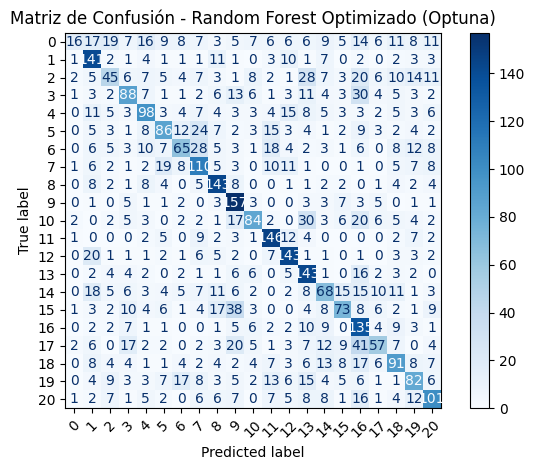


✅ Entrenamiento y optimización completados correctamente
📊 Accuracy (Train): 92.26%
📊 Accuracy (Test) : 49.90%
📉 Diferencia (Overfitting): 42.36%
📁 Modelo y métricas guardados en: ..\backend\models


In [9]:
# -----------------------------
# 7️⃣ Métricas detalladas
# -----------------------------
out_dir = Path("../backend/models")
out_dir.mkdir(parents=True, exist_ok=True)

report = classification_report(y_test, y_pred_test, digits=3, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(out_dir / "classification_report_rf_optuna.csv")

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Random Forest Optimizado (Optuna)")
plt.tight_layout()
plt.savefig(out_dir / "confusion_matrix_rf_optuna.png")
plt.show()

# -----------------------------
# 8️⃣ Guardar modelo, PCA y scaler
# -----------------------------
model_path = out_dir / "random_forest_model_optuna.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

with open(out_dir / "pca_scaler_optuna.pkl", "wb") as f:
    pickle.dump({"pca": pca, "scaler": scaler}, f)

print("\n==============================================================")
print("✅ Entrenamiento y optimización completados correctamente")
print(f"📊 Accuracy (Train): {train_acc*100:.2f}%")
print(f"📊 Accuracy (Test) : {test_acc*100:.2f}%")
print(f"📉 Diferencia (Overfitting): {diff:.2f}%")
print(f"📁 Modelo y métricas guardados en: {out_dir}")
print("==============================================================")